In [ ]:
! pip install pgmpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 43.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (6,3)
from seaborn import heatmap
from pgmpy.estimators import TreeSearch
import networkx as nx
from google.colab import files
import io

In [ ]:
# upload data from spreadsheet ('MSCI_Emerging_Markets_Factor_Index.xlsx')
# because the MSCI website is a dynamic website, not sure how to scrape from that
# can use Selenium but it looks quite involved ...
uploaded = files.upload()

Saving MSCI_Emerging_Markets_Factor_Index.xlsx to MSCI_Emerging_Markets_Factor_Index.xlsx


In [ ]:
fil = [i for i in uploaded.keys()]
df = pd.read_excel(io.BytesIO(uploaded[fil[0]]), header=5, usecols="A:F")
df.columns = ["DATE", "MOM", "GRW", "VLU", "QLT", "LOW"]
# MOM: Momentum
# GRW: Growth
# VLU: Value
# QLT: Quality
# LOW: Low volatility

df['DATE'] = pd.to_datetime(df['DATE'], format="%Y-%m-%d")
df.index = df['DATE']
del df['DATE']
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6552 entries, 2000-05-31 to 2025-09-12
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   MOM     6552 non-null   float64
 1   GRW     6552 non-null   float64
 2   VLU     6552 non-null   float64
 3   QLT     6552 non-null   float64
 4   LOW     6552 non-null   float64
dtypes: float64(5)
memory usage: 307.1 KB


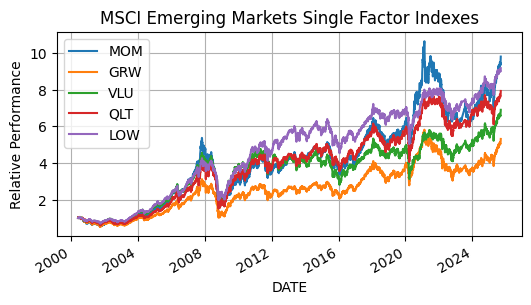

In [ ]:
# plot cumulative returns
ret_df = df.copy().pct_change().dropna()
(1 + ret_df).cumprod().plot()
plt.ylabel("Relative Performance")
plt.title("MSCI Emerging Markets Single Factor Indexes")
plt.grid()
plt.show()

In [ ]:
# discretize returns
ret_df1 = pd.DataFrame(index=ret_df.index)
for x in ret_df.columns:
    ret_df1[x] = np.where(ret_df[x] > 0, 1, 0)

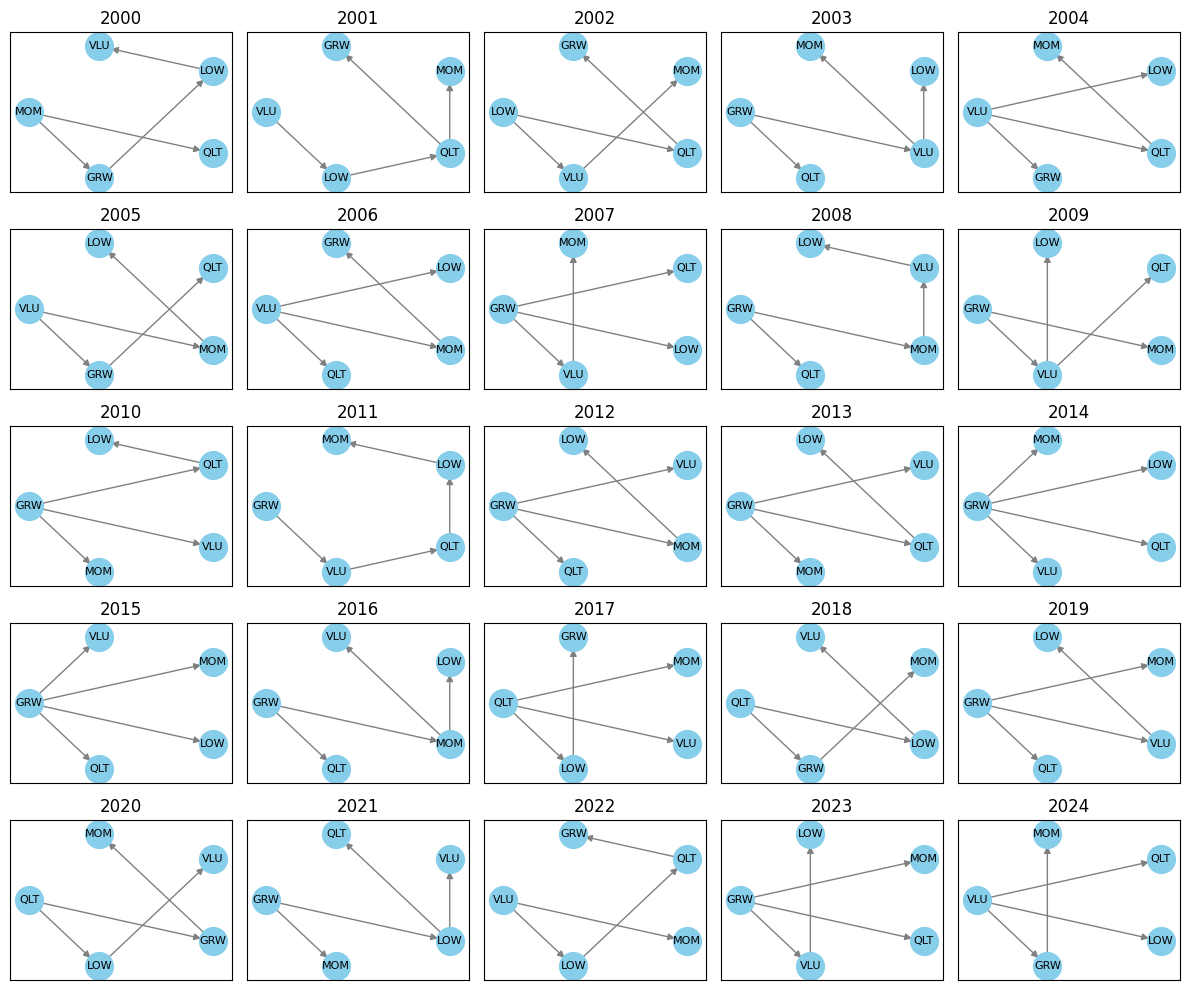

In [ ]:
# plot DAG by year
row, col = 5, 5
fig, axes = plt.subplots(row, col, figsize=(12,10))
y = 2000

for r in range(row):
    for c in range(col):

        # estimate graph structure
        year_df1 = ret_df1.iloc[ret_df.index.year == y,:]
        ts = TreeSearch(year_df1)
        model = ts.estimate(estimator_type='chow-liu',
                            edge_weights_fn='mutual_info',
                            show_progress=False)

        # draw graphs using networkX
        G = nx.DiGraph(ax=axes[r,c])
        G.add_edges_from(model.edges(), ax=axes[r,c])
        pos = nx.shell_layout(G)
        nx.draw_networkx_nodes(G, pos, ax=axes[r,c], node_size=400, node_color='skyblue')
        nx.draw_networkx_edges(G, pos, ax=axes[r,c], arrows=True, edge_color='gray')
        nx.draw_networkx_labels(G, pos, ax=axes[r,c], font_size=8)
        axes[r,c].set_title(f"{y}")

        y += 1
plt.tight_layout()
plt.show()

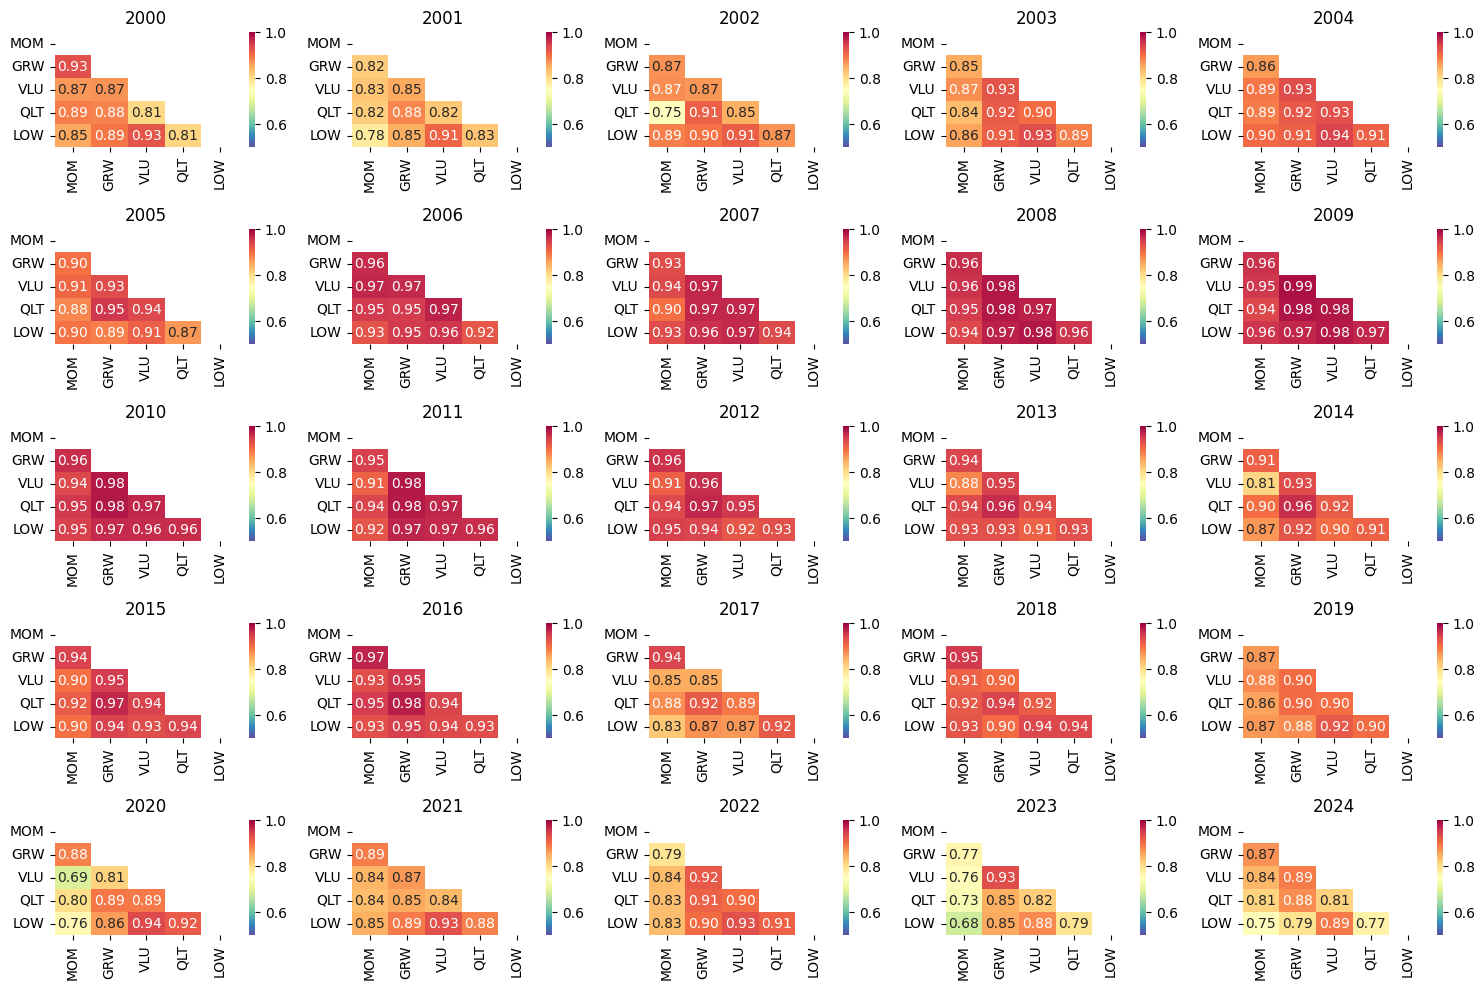

In [ ]:
# plot correlations by year
fig, axes = plt.subplots(row, col, figsize=(15,10))
y = 2000

for r in range(row):
    for c in range(col):
        year_df = ret_df.iloc[ret_df.index.year == y,:]
        corr = year_df.corr(method='spearman')
        mask = np.triu(np.ones_like(corr, dtype=bool))
        heatmap(corr,
                annot=True,
                cmap='Spectral_r',
                fmt=".2f",
                vmax=1.0,
                vmin=0.5,
                mask=mask,
                ax=axes[r,c])
        axes[r,c].set_title(f"{y}")
        y += 1
plt.tight_layout()
plt.show()